# Ridge Regression - Custom class
> #### <span style = 'color:orange; font-family:caveat'>for Multivariate Dataset</span>

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

In [2]:
# load dataset
from sklearn.datasets import load_diabetes
x,y = load_diabetes(return_X_y=True)

In [3]:
# data split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=2)

## sklearn - Ridge Regression

In [9]:
r = Ridge(alpha=0.1, solver='cholesky')
r.fit(x_train, y_train)
y_pred_sk = r.predict(x_test)

print('Intercept: ',r.intercept_)
print('Coef: ',r.coef_)
print('R2 score: ',r2_score(y_test, y_pred_sk))

Intercept:  151.92546856900984
Coef:  [   6.64373321 -172.23747375  485.52958514  314.67584612  -72.94020918
  -80.58868817 -174.46352722   83.61470987  484.36531622   73.58509056]
R2 score:  0.4519949419719548


## class - Ridge Regression

In [10]:
class ridge_reg:
    def __init__(self, alpha = 0.1):
        self.intercept_ = None
        self.coef_ = None
        self.alpha = alpha
    
    def fit(self, x_train, y_train):
        x_train = np.insert(x_train, 0, 1, axis=1)
        id = np.identity(x_train.shape[1])      # identity matrix
        id[0,0] = 0
        part_1 = (x_train.T @ x_train) + (self.alpha * id)
        inv_part1 = np.linalg.inv(part_1)
        part_2 = x_train.T @ y_train

        betas = np.dot(inv_part1, part_2)
        self.intercept_ = betas[0]
        self.coef_ = betas[1: ]

        print('Intercept: ',self.intercept_)
        print('Coef: ',self.coef_)
        
    def predict(self,x_test):
        return self.intercept_ + np.dot(x_test, self.coef_)

### id[0,0] = 0
#### We set id[0,0] = 0 because Ridge regression should penalize only the feature weights, not the intercept (bias), since the intercept only shifts the prediction up or down and does not increase model complexity.

In [11]:
rr = ridge_reg(alpha=0.1)
rr.fit(x_train, y_train)
y_pred_rr = rr.predict(x_test)

# print('Intercept: ',rr.intercept_)
# print('Coef: ',rr.coef_)
print('R2 score: ',r2_score(y_test, y_pred_rr))

Intercept:  151.92546856900987
Coef:  [   6.64373321 -172.23747375  485.52958514  314.67584612  -72.94020918
  -80.58868817 -174.46352722   83.61470987  484.36531622   73.58509056]
R2 score:  0.45199494197195456


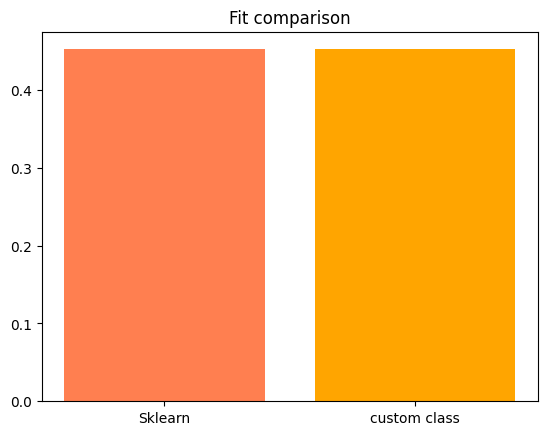

False

In [15]:
import matplotlib.pyplot as plt

data = {
    'Sklearn':r2_score(y_test, y_pred_sk),
    'custom class':r2_score(y_test, y_pred_rr)
}
plt.bar(data.keys(), data.values(), color = ['coral','orange'])
plt.title('Fit comparison')
plt.show()

sk = r2_score(y_test, y_pred_sk)
cc = r2_score(y_test, y_pred_rr)

sk <= cc
